# Home Cage Dopamine Analysis

In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(PROJECT_ROOT)

from trial_class import *
from experiment_class import Experiment

from hc_extension import *
from bouts_extension import *

In [2]:
# NAc: #15616F
# mPFC: #FFAF00

# NAc
nac_experiment_path = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\nac"
nac_csv_base_path = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\nac_csvs"
nac_color = '#15616F'


# mPFC
mpfc_experiment_path = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\mpfc"
mpfc_csv_base_path = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\mpfc_csvs"
mpfc_color = '#FFAF00'

In [3]:
# groups csv + experiment data into one variable
nac_exp = Experiment(nac_experiment_path, nac_csv_base_path)

mpfc_exp = Experiment(mpfc_experiment_path, mpfc_csv_base_path)

# batch process the data, removing the specified time segments for subjects
nac_exp.default_batch_process()

mpfc_exp.default_batch_process()

Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\nac\n5-240823-085032\Notes.txt
read from t=0s to t=1789.26s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\nac\n6-240823-101436\Notes.txt
read from t=0s to t=1793.07s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\nac\n7-240824-062103\Notes.txt
read from t=0s to t=1803.56s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\nac\nn1-250120-063024\Notes.txt
read from t=0s to t=1833.87s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\nac\nn2-250120-072910\Notes.txt
read from t=0s to t=1774.16s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\nac\nn3-250121-074834\Notes.txt
read f

In [4]:
bout_definitions = [
    {'prefix': 'Short_Term', 'introduced': 'Short_Term_Introduced', 'removed': 'Short_Term_Removed'},
    {'prefix': 'Long_Term', 'introduced': 'Long_Term_Introduced', 'removed': 'Long_Term_Removed'},
    {'prefix': 'Novel', 'introduced': 'Novel_Introduced', 'removed': 'Novel_Removed'}
]

nac_exp.group_extract_manual_annotations(bout_definitions=bout_definitions, first_only = False)

mpfc_exp.group_extract_manual_annotations(bout_definitions=bout_definitions, first_only = True)

# total_avg_bout_duration = metadata_df["Average Bout Duration"].mean()
# print(f"Total Average Bout Duration: {total_avg_bout_duration:.4f}")
# Proceed with DA metric computation after all files are processed
nac_exp.compute_all_da_metrics(use_max_length=False,
                                  max_bout_duration=4, #otal_avg_bout_duration
                                  mode='standard')

mpfc_exp.compute_all_da_metrics(use_max_length=False,
                                  max_bout_duration=4, #otal_avg_bout_duration
                                  mode='standard')

Processing behaviors for n5-240823-085032...
Processing behaviors for n6-240823-101436...
Processing behaviors for n7-240824-062103...
Processing behaviors for nn1-250120-063024...
Processing behaviors for nn2-250120-072910...
Processing behaviors for nn3-250121-074834...
Processing behaviors for nn4-250121-084228...
Processing behaviors for nn5-250120-081227...
Processing behaviors for nn6-250120-085156...
Processing behaviors for nn7-250121-094048...
Processing behaviors for nn8-250121-101912...
Processing behaviors for p1-240508-084607...
Processing behaviors for p2-240508-101128...
Processing behaviors for p3-240509-070801...
Processing behaviors for p5-240823-093250...
Processing behaviors for p6-240823-105552...
Processing behaviors for p7-240824-053845...
Processing behaviors for p8-240824-070451...
Processing behaviors for pp1-250120-094415...
Processing behaviors for pp2-250121-123301...
Processing behaviors for pp3-250121-055222...
Processing behaviors for pp4-250121-065035..

### Peak standard z-score

In [5]:
nac_exp_da_dict = get_trial_dataframes(nac_exp)
mpfc_exp_da_dict = get_trial_dataframes(mpfc_exp)

In [6]:
desired_bouts = ['Short_Term-1', 'Novel-1', 'Short_Term-2', 'Long_Term-1']

nac_da_metadata_df = create_da_metrics_dataframe(nac_exp_da_dict, behavior="Investigation", desired_bouts=desired_bouts)

mpfc_da_metadata_df = create_da_metrics_dataframe(mpfc_exp_da_dict, behavior="Investigation", desired_bouts=desired_bouts)

In [7]:
# Copy original DataFrame
nac_ordered_df = nac_da_metadata_df.copy()

mpfc_ordered_df = mpfc_da_metadata_df.copy()

desired_bout_order = ["Short_Term-1", "Short_Term-2", "Long_Term-1", "Novel-1"]

# 1. Filter and reorder Bout as categorical
nac_ordered_df = nac_ordered_df[nac_ordered_df["Bout"].isin(desired_bout_order)].copy()
nac_ordered_df["Bout"] = pd.Categorical(nac_ordered_df["Bout"], categories=desired_bout_order, ordered=True)

mpfc_ordered_df = mpfc_ordered_df[mpfc_ordered_df["Bout"].isin(desired_bout_order)].copy()
mpfc_ordered_df["Bout"] = pd.Categorical(mpfc_ordered_df["Bout"], categories=desired_bout_order, ordered=True)

In [8]:
nac_ordered_df.head()

,Subject,Bout,Behavior,AUC,Max Peak,Mean Z-score
0,n5,Short_Term-1,Investigation,3.944767,1.696934,0.060702
1,n5,Novel-1,Investigation,8.274450,2.166439,0.432728
2,n5,Short_Term-2,Investigation,-0.799824,0.771270,-0.147484
3,n5,Long_Term-1,Investigation,1.009236,0.725498,0.005914
4,n6,Short_Term-1,Investigation,0.986148,0.931508,0.157431


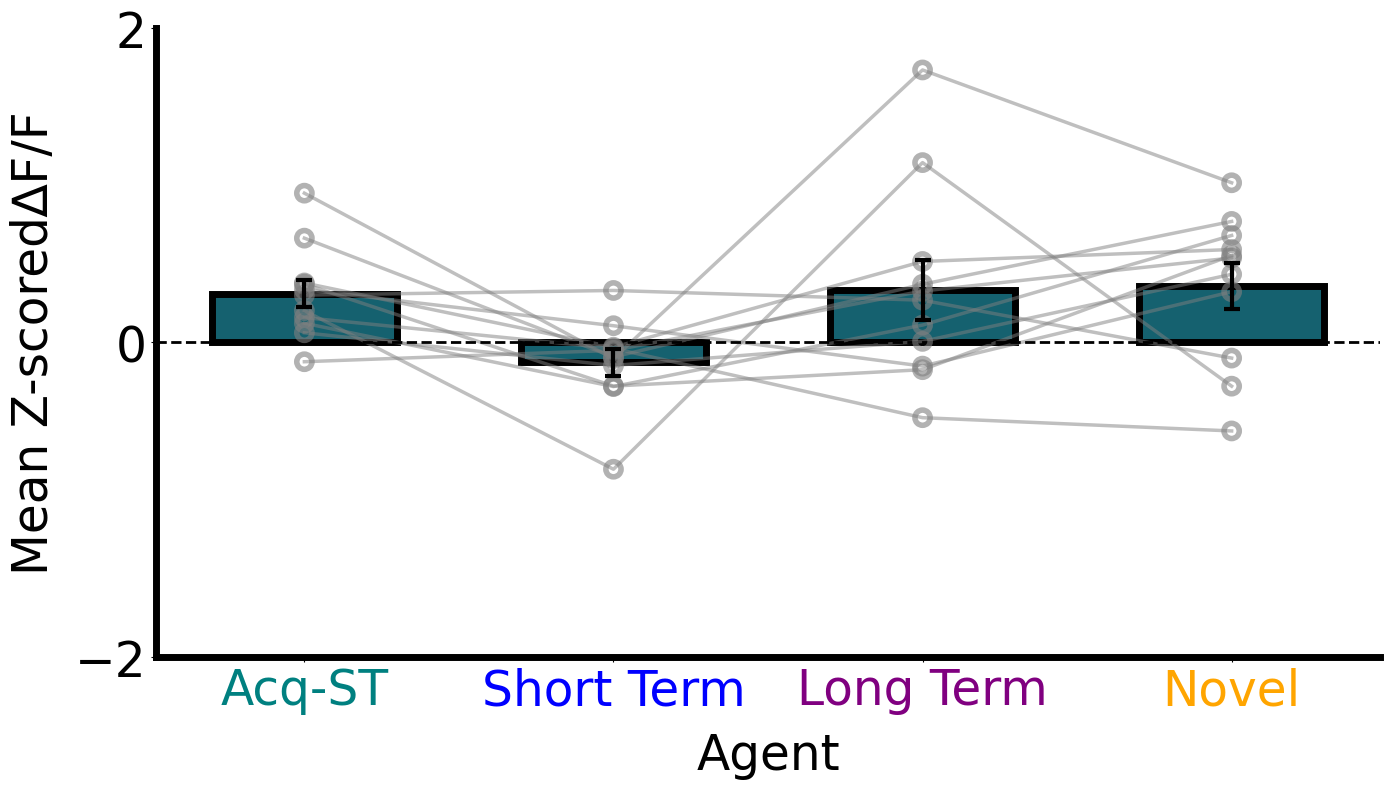


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 11  3.7627   0.0037   1.1345
 Short_Term-1 vs Long_Term-1 11 -0.1454   0.8873  -0.0438
     Short_Term-1 vs Novel-1 11 -0.3792   0.7125  -0.1143
 Short_Term-2 vs Long_Term-1 11 -1.9779   0.0761  -0.5964
     Short_Term-2 vs Novel-1 11 -3.0171   0.0130  -0.9097
      Long_Term-1 vs Novel-1 11 -0.1361   0.8944  -0.0410


In [9]:
nac_pivot_df, nac_stats_df = plot_behavior_across_bouts_no_identities(
    metadata_df=nac_ordered_df,
    y_col="Mean Z-score",
    ylabel="Mean Z-scored∆F/F",
    xlabel="Agent",
    custom_xtick_labels=["Acq-ST", "Short Term", "Long Term", "Novel"],
    custom_xtick_colors=["teal", "blue", "purple", "orange"],
    ylim=(-2, 2),
    yticks_increment=2,
    bar_color=nac_color,
    figsize=(14, 8),
    save=None,
    save_name ="mDA",
    title=None
)

In [ ]:
nac_da_metadata_df = create_da_metrics_first_instance(
    nac_exp_da_dict,
    behavior="Investigation",
    desired_bouts=desired_bouts,
    time_col="Event_Start"
)



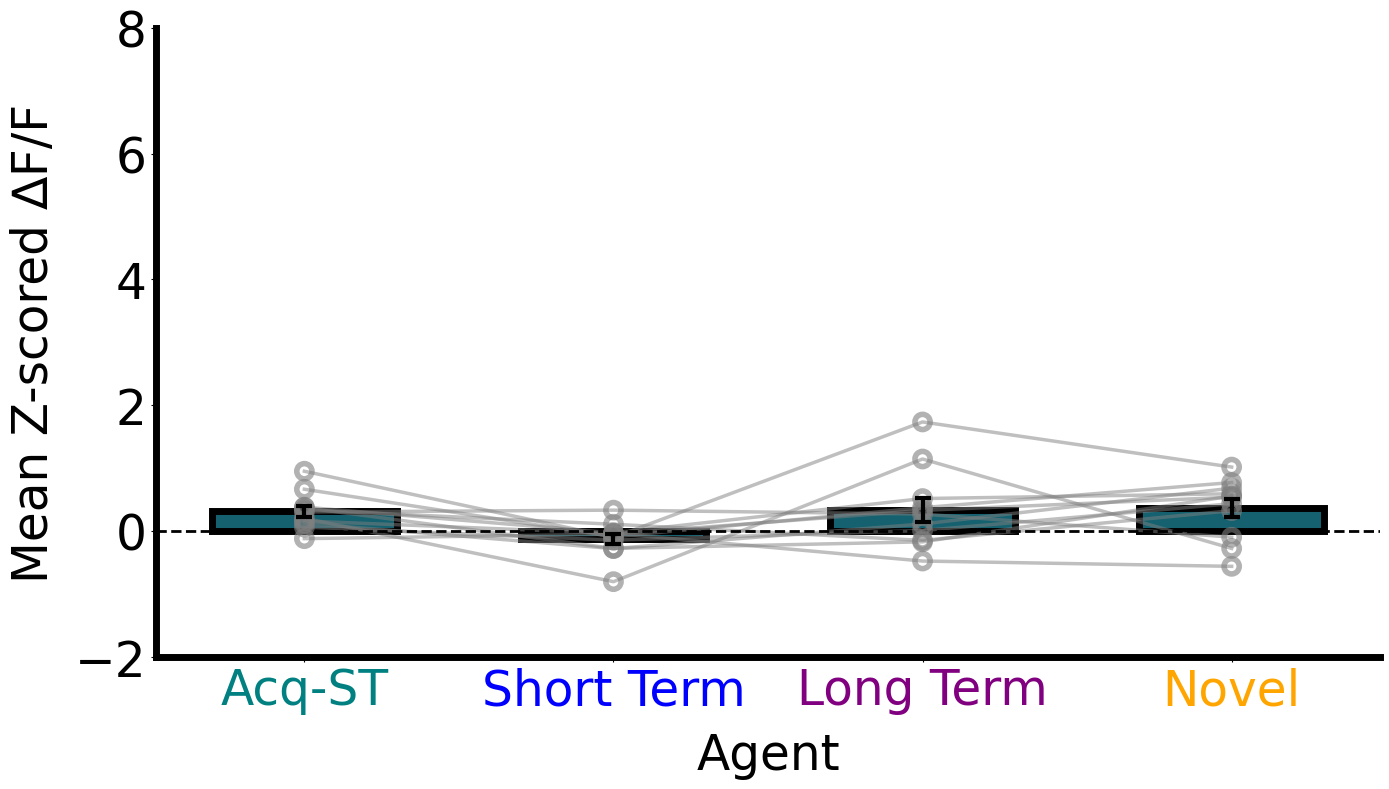


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 11  3.7627   0.0037   1.1345
 Short_Term-1 vs Long_Term-1 11 -0.1454   0.8873  -0.0438
     Short_Term-1 vs Novel-1 11 -0.3792   0.7125  -0.1143
 Short_Term-2 vs Long_Term-1 11 -1.9779   0.0761  -0.5964
     Short_Term-2 vs Novel-1 11 -3.0171   0.0130  -0.9097
      Long_Term-1 vs Novel-1 11 -0.1361   0.8944  -0.0410


In [11]:
nac_pivot_df, nac_stats_df = plot_behavior_across_bouts_no_identities(
    metadata_df=nac_ordered_df,
    y_col="Mean Z-score",
    ylabel="Mean Z-scored ∆F/F",
    xlabel="Agent",
    custom_xtick_labels=["Acq-ST", "Short Term", "Long Term", "Novel"],
    custom_xtick_colors=["teal", "blue", "purple", "orange"],
    ylim=(-2, 8),
    yticks_increment=2,
    bar_color=nac_color,
    figsize=(14, 8),
    save=None,
    save_name ="mDA",
    title=None
)

In [12]:
# bon_results = apply_multiple_comparisons(
#     nac_stats_df,
#     method='holm',
#     alpha=0.05,
#     comparisons=["s1-1 vs s1-2", "s1-5 vs s2-1"]
# )

In [51]:
mpfc_da_metadata_df = create_da_metrics_first_instance(
    mpfc_exp_da_dict,
    behavior="Investigation",
    desired_bouts=desired_bouts,
    time_col="Event_Start"
)

# Copy original DataFrame
nac_ordered_df = nac_da_metadata_df.copy()

mpfc_ordered_df = mpfc_da_metadata_df.copy()

desired_bout_order = ["Short_Term-1", "Short_Term-2", "Long_Term-1", "Novel-1"]

# 1. Filter and reorder Bout as categorical
nac_ordered_df = nac_ordered_df[nac_ordered_df["Bout"].isin(desired_bout_order)].copy()
nac_ordered_df["Bout"] = pd.Categorical(nac_ordered_df["Bout"], categories=desired_bout_order, ordered=True)

mpfc_ordered_df = mpfc_ordered_df[mpfc_ordered_df["Bout"].isin(desired_bout_order)].copy()
mpfc_ordered_df["Bout"] = pd.Categorical(mpfc_ordered_df["Bout"], categories=desired_bout_order, ordered=True)

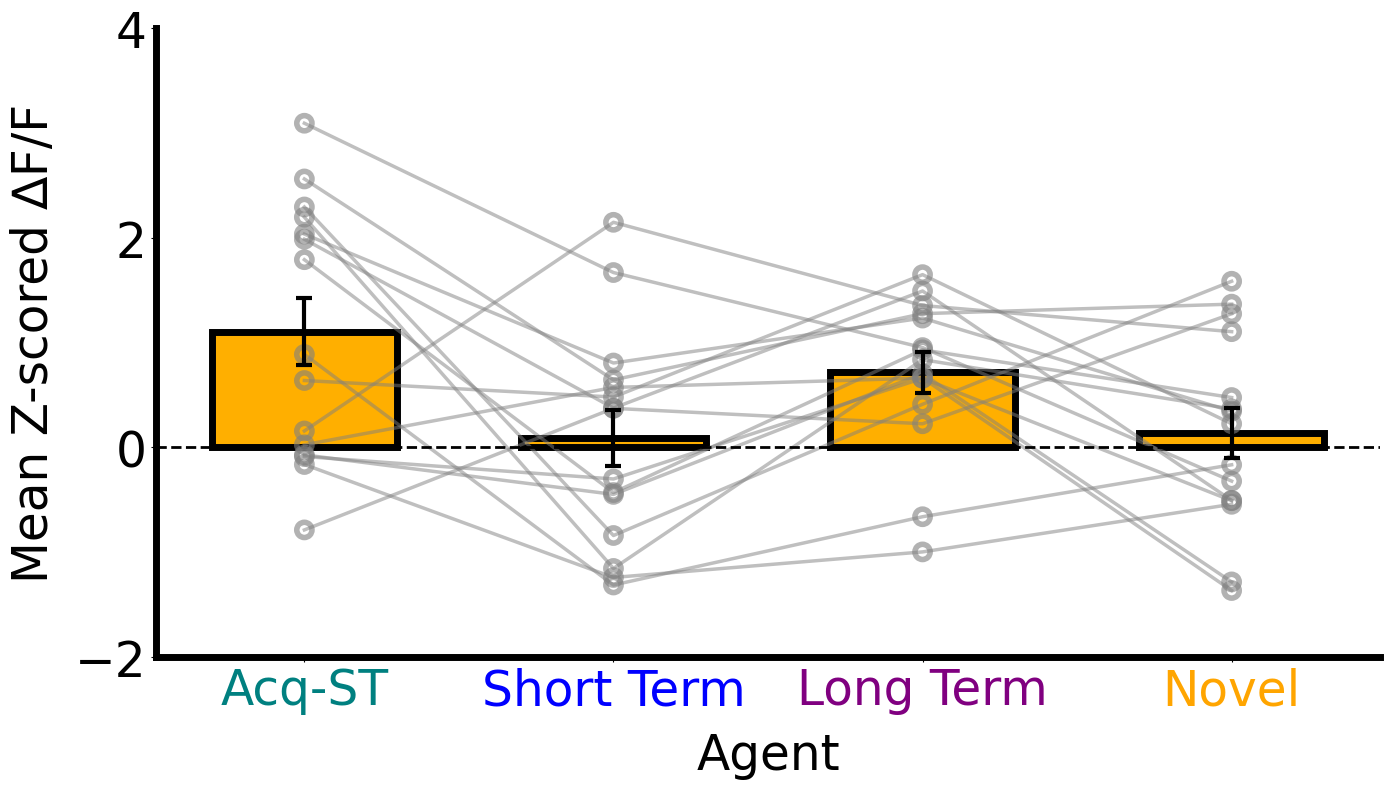


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 15  2.5917   0.0213   0.6692
 Short_Term-1 vs Long_Term-1 15  1.2877   0.2187   0.3325
     Short_Term-1 vs Novel-1 15  2.8687   0.0124   0.7407
 Short_Term-2 vs Long_Term-1 15 -3.0920   0.0080  -0.7984
     Short_Term-2 vs Novel-1 15 -0.1451   0.8867  -0.0375
      Long_Term-1 vs Novel-1 15  2.0785   0.0565   0.5367


In [57]:
mpfc_pivot_df, mpfc_stats_df = plot_behavior_across_bouts_no_identities(
    metadata_df=mpfc_ordered_df,
    y_col="Mean Z-score",
    ylabel="Mean Z-scored ∆F/F",
    xlabel="Agent",
    custom_xtick_labels=["Acq-ST", "Short Term", "Long Term", "Novel"],
    custom_xtick_colors=["teal", "blue", "purple", "orange"],
    ylim=(-2, 4),
    yticks_increment=2,
    bar_color=mpfc_color,
    figsize=(14, 8),
    save=None,
    save_name ="mDA",
    title=None
)

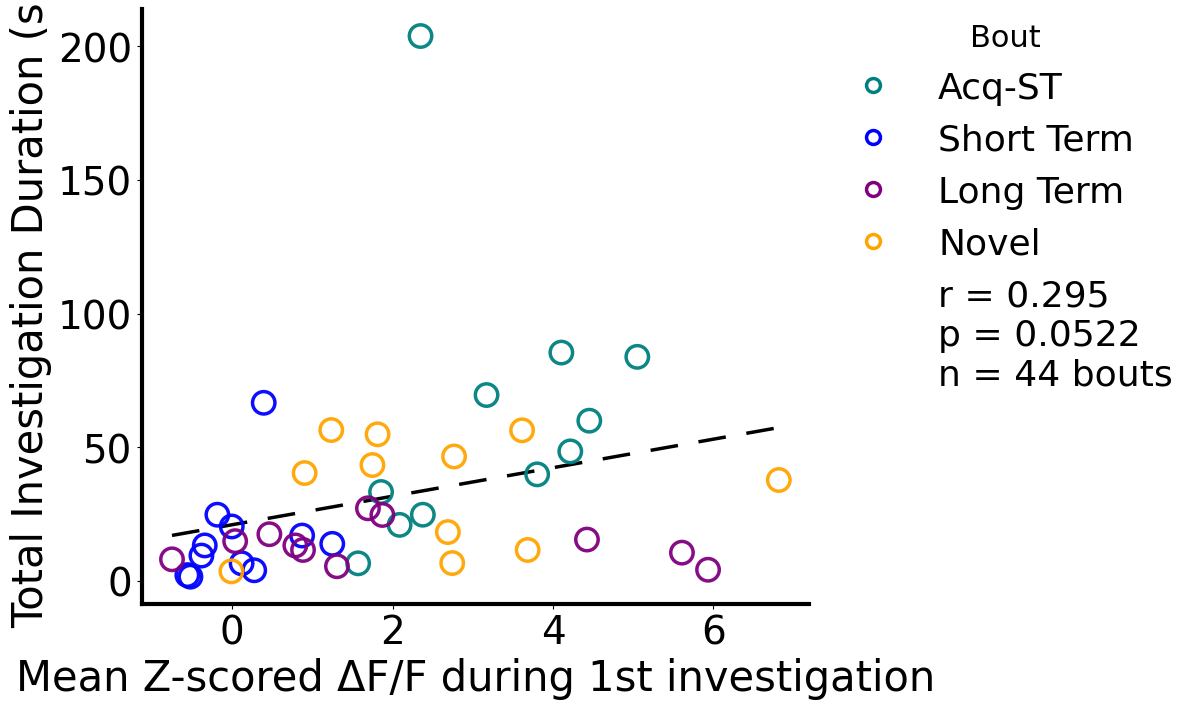

In [14]:
from matplotlib.lines import Line2D

group_order = ["Acq-ST", "Short Term", "Long Term", "Novel"]
group_colors = {
    "Acq-ST": "#008080",
    "Short Term": "#0000FF",
    "Long Term": "#800080",
    "Novel": "#FFA500",
}


summary_df, plot_df, fig, ax = plot_first_investigation_da_vs_total_duration_from_experiment(
    experiment=nac_exp,
    desired_bouts=["Short_Term-1", "Short_Term-2", "Long_Term-1", "Novel-1"],
    group_label_map={
        "Short_Term-1": "Acq-ST",
        "Short_Term-2": "Short Term",
        "Long_Term-1": "Long Term",
        "Novel-1": "Novel",
    },
    group_col="Group",
    group_order=group_order,
    xlabel="Mean Z-scored ΔF/F during 1st investigation",
    ylabel="Total Investigation Duration (s)",
    figsize=(11, 8),
    group_colors=group_colors,
    stats_loc=(1.02, 0.75),
)

stats_text = "\n".join(text.get_text() for text in ax.texts if text.get_text())
for text in ax.texts:
    text.remove()

ax.set_title("")
ax.xaxis.label.set_size(30)
ax.yaxis.label.set_size(30)
ax.tick_params(axis="both", labelsize=28)

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor="none",
        markeredgecolor=group_colors[group],
        markeredgewidth=2.5,
        markersize=10,
        label=group,
    )
    for group in group_order
]
legend_handles.append(Line2D([0], [0], linestyle="None", label=stats_text))

ax.legend(
    handles=legend_handles,
    title="Bout",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
    frameon=False,
    fontsize=26,
    title_fontsize=22,
)

plt.tight_layout(rect=(0, 0, 1.1, 0.9))

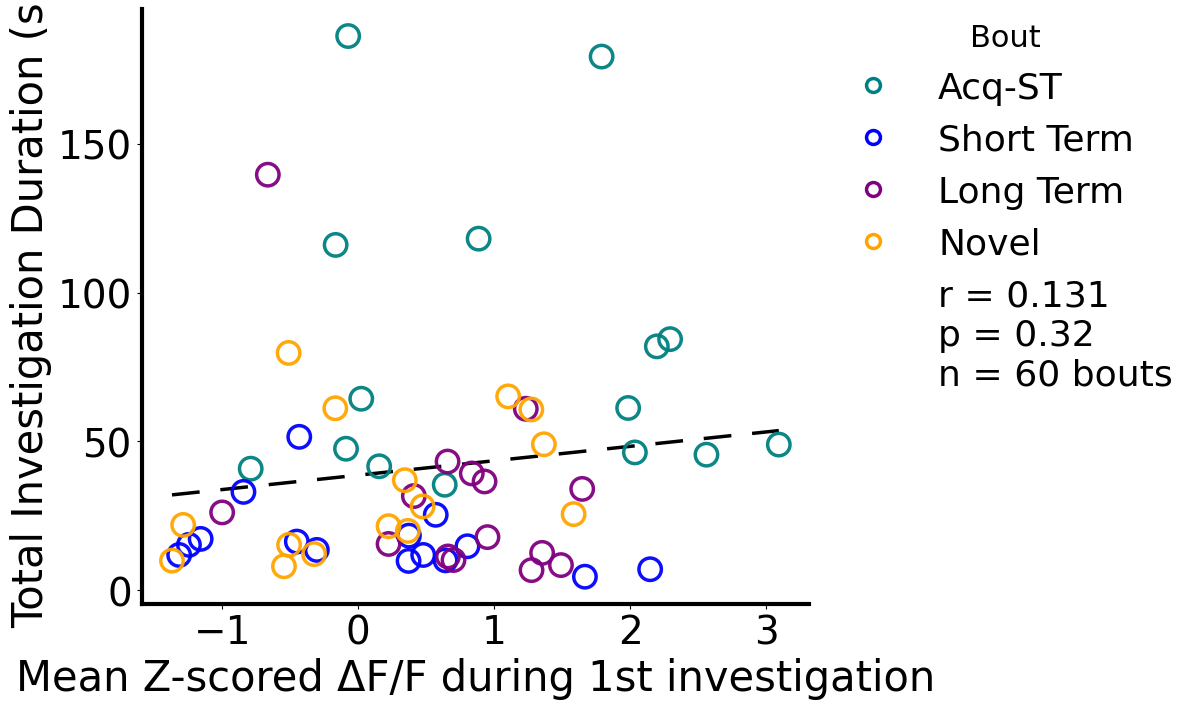

In [43]:
from matplotlib.lines import Line2D

group_order = ["Acq-ST", "Short Term", "Long Term", "Novel"]
group_colors = {
   "Acq-ST": "#008080",
    "Short Term": "#0000FF",
    "Long Term": "#800080",
    "Novel": "#FFA500",
}

summary_df, plot_df, fig, ax = plot_first_investigation_da_vs_total_duration_from_experiment(
    experiment=mpfc_exp,
    desired_bouts=["Short_Term-1", "Short_Term-2", "Long_Term-1", "Novel-1"],
    group_label_map={
        "Short_Term-1": "Acq-ST",
        "Short_Term-2": "Short Term",
        "Long_Term-1": "Long Term",
        "Novel-1": "Novel",
    },
    group_col="Group",
    group_order=group_order,
    xlabel="Mean Z-scored ΔF/F during 1st investigation",
    ylabel="Total Investigation Duration (s)",
    figsize=(11, 8),
    group_colors=group_colors,
    stats_loc=(1.02, 0.75),
)

stats_text = "\n".join(text.get_text() for text in ax.texts if text.get_text())
for text in ax.texts:
    text.remove()

ax.set_title("")
ax.xaxis.label.set_size(30)
ax.yaxis.label.set_size(30)
ax.tick_params(axis="both", labelsize=28)

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor="none",
        markeredgecolor=group_colors[group],
        markeredgewidth=2.5,
        markersize=10,
        label=group,
    )
    for group in group_order
]
legend_handles.append(Line2D([0], [0], linestyle="None", label=stats_text))

ax.legend(
    handles=legend_handles,
    title="Bout",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
    frameon=False,
    fontsize=26,
    title_fontsize=22,
)

plt.tight_layout(rect=(0, 0, 1.1, 0.9))


## Rank analysis

In [16]:


from hc_extension import *

ranks = find_ranks_using_ds(
    file_path=r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\combined_cohorts\manual_scoring_combined.xlsx"
)

ranks

c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Home_Cage\hc_extension.py:181: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_df = empty_df.fillna(0).infer_objects(copy=False)


,ID,DS,Cage,Rank
0,n1,-2.839098,n1,4
1,n2,-0.739850,n1,3
2,n3,3.263158,n1,1
3,n4,0.315789,n1,2
4,n5,2.643609,n2,1
5,n6,0.282707,n2,2
6,n7,-0.331721,n2,3
8,nn1,-1.967742,nn1,4
9,nn2,0.497076,nn1,2
10,nn3,-1.503268,nn1,3


In [17]:
lt_rank_summary = build_home_cage_long_term_rank_summary(
    experiment=nac_exp,
    rank_source=ranks,
    mapping_source=r"C:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Home_Cage\Cagemate_mapping.xlsx",
    da_col="Mean Z-score",
)

In [18]:
assign_subject_ranks_to_experiment(nac_exp, ranks)

Ranks assigned to 8 trials.
No rank found for trials: ['n5-240823-085032', 'n6-240823-101436', 'n7-240824-062103']


In [19]:
ranks

,ID,DS,Cage,Rank
0,n1,-2.839098,n1,4
1,n2,-0.739850,n1,3
2,n3,3.263158,n1,1
3,n4,0.315789,n1,2
4,n5,2.643609,n2,1
5,n6,0.282707,n2,2
6,n7,-0.331721,n2,3
8,nn1,-1.967742,nn1,4
9,nn2,0.497076,nn1,2
10,nn3,-1.503268,nn1,3


In [20]:
lt_rank_summary[['Subject','Subject Rank','Agent Rank']]

,Subject,Subject Rank,Agent Rank
0,n5,1,3.0
1,n6,2,NaN
2,n7,3,2.0
3,nn1,4,3.0
4,nn2,2,1.0
5,nn3,3,2.0
6,nn4,1,4.0
7,nn5,4,3.0
8,nn6,2,1.0
9,nn7,3,2.0


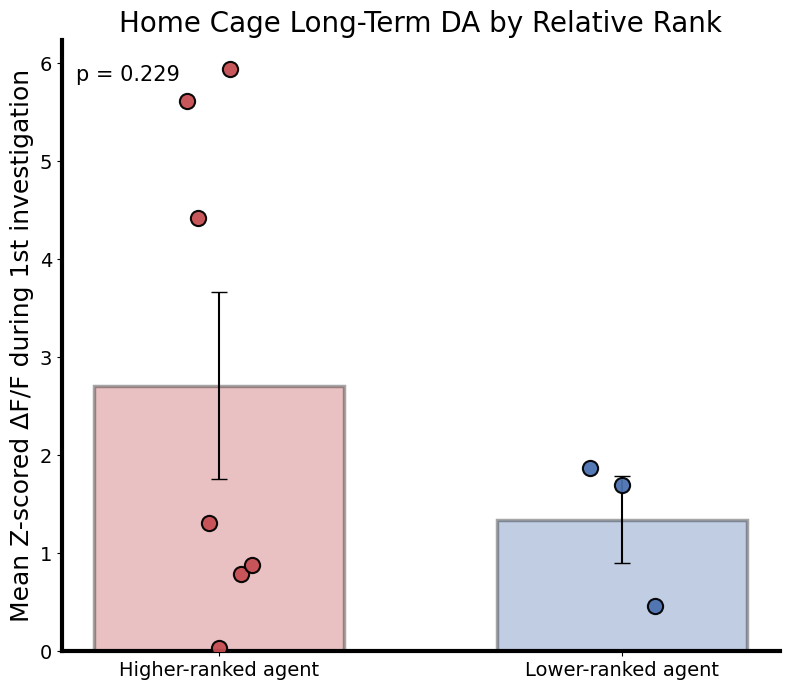

In [21]:
plot_df_rel, fig, ax = plot_home_cage_long_term_da_by_relative_rank(
    lt_rank_summary,
    da_col="DA",
    title="Home Cage Long-Term DA by Relative Rank",
    ylabel="Mean Z-scored ΔF/F during 1st investigation",
)

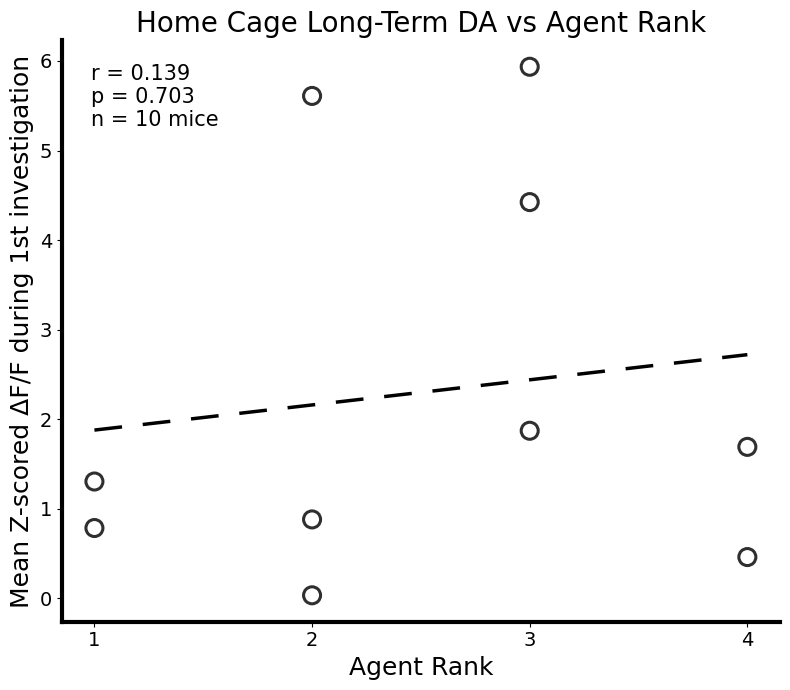

In [22]:
plot_df_rank, fig, ax = plot_home_cage_long_term_da_vs_rank(
    lt_rank_summary,
    rank_col="Agent Rank",
    da_col="DA",
    title="Home Cage Long-Term DA vs Agent Rank",
    xlabel="Agent Rank",
    ylabel="Mean Z-scored ΔF/F during 1st investigation",
)

(   Subject         Bout Agent  Subject Rank  Agent Rank        Relative Rank  \
 0       n5  Long_Term-1    n7             1         3.0   Lower-ranked agent   
 1       n6  Long_Term-1    n8             2         NaN                  NaN   
 2       n7  Long_Term-1    n6             3         2.0  Higher-ranked agent   
 3      nn1  Long_Term-1   nn3             4         3.0  Higher-ranked agent   
 4      nn2  Long_Term-1   nn4             2         1.0  Higher-ranked agent   
 5      nn3  Long_Term-1   nn2             3         2.0  Higher-ranked agent   
 6      nn4  Long_Term-1   nn1             1         4.0   Lower-ranked agent   
 7      nn5  Long_Term-1   nn7             4         3.0  Higher-ranked agent   
 8      nn6  Long_Term-1   nn8             2         1.0  Higher-ranked agent   
 9      nn7  Long_Term-1   nn6             3         2.0  Higher-ranked agent   
 10     nn8  Long_Term-1   nn5             1         4.0   Lower-ranked agent   
 
     Rank Difference  Firs

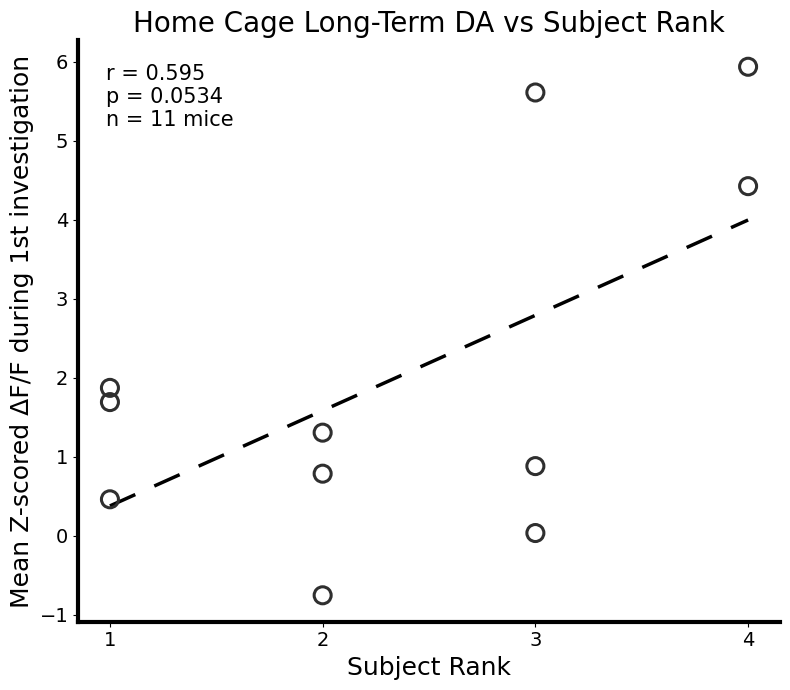

In [23]:
plot_home_cage_long_term_da_vs_rank(
    lt_rank_summary,
    rank_col="Subject Rank",
    da_col="DA",
    title="Home Cage Long-Term DA vs Subject Rank",
    xlabel="Subject Rank",
)

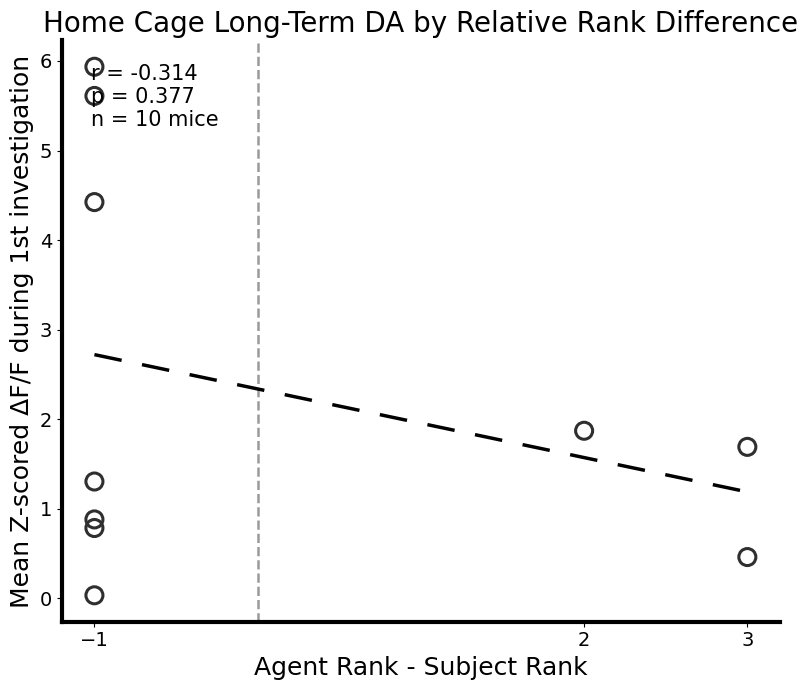

In [24]:
plot_df_rank_diff, fig, ax = plot_home_cage_long_term_da_vs_rank_difference(
    lt_rank_summary,
    da_col="DA",
    title="Home Cage Long-Term DA by Relative Rank Difference",
    xlabel="Agent Rank - Subject Rank",
    ylabel="Mean Z-scored ΔF/F during 1st investigation",
    figsize=(8, 7),
)


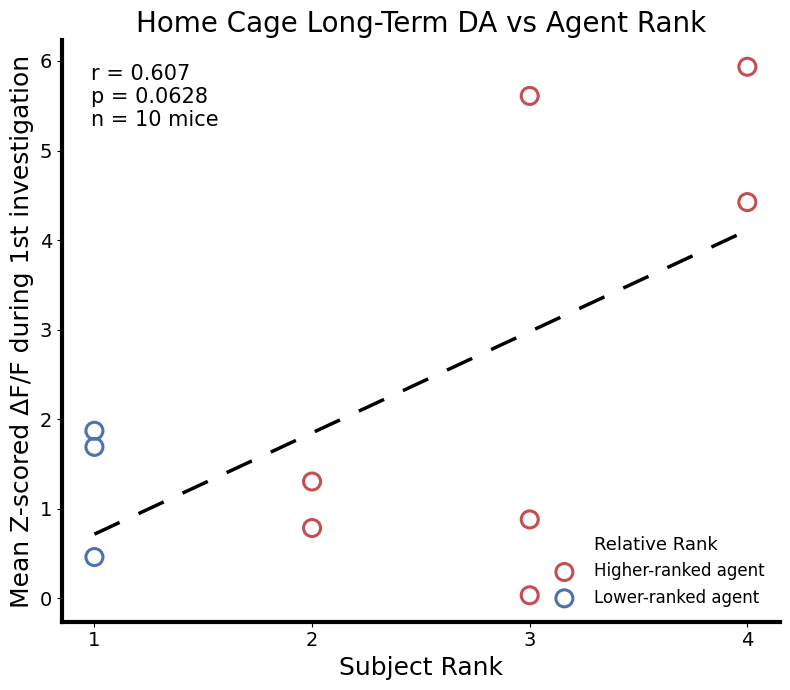

In [56]:
plot_df_rank, fig, ax = plot_home_cage_long_term_da_vs_rank_colored(
    lt_rank_summary,
    rank_col="Subject Rank",
    da_col="DA",
    color_col="Relative Rank",
    color_order=["Higher-ranked agent", "Lower-ranked agent", "Equal-ranked agent"],
    color_map={
        "Higher-ranked agent": "#c44e52",
        "Lower-ranked agent": "#4c72b0",
        "Equal-ranked agent": "#7f7f7f",
    },
    legend_title="Relative Rank",
    title="Home Cage Long-Term DA vs Agent Rank",
    xlabel="Subject Rank",
    ylabel="Mean Z-scored ΔF/F during 1st investigation",
)

,Subject Rank,Agent Rank,mean,count,std,sem
0,1,3.0,1.871658,1,NaN,0.000000
1,1,4.0,1.076780,2,0.869706,0.614975
2,2,1.0,1.045497,2,0.367083,0.259567
3,3,2.0,2.175353,3,3.003894,1.734299
4,4,3.0,5.179644,2,1.068252,0.755368


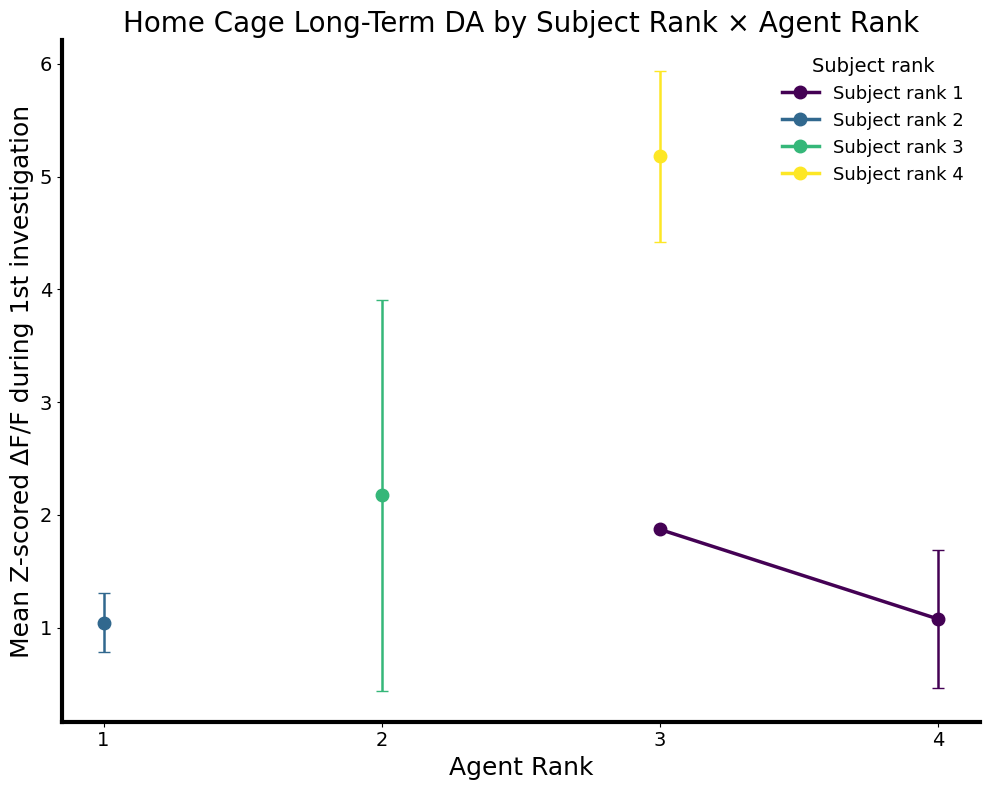

In [25]:
plot_df_interaction, interaction_summary, fig, ax = plot_home_cage_long_term_da_rank_interaction(
    lt_rank_summary,
    da_col="DA",
    title="Home Cage Long-Term DA by Subject Rank × Agent Rank",
    xlabel="Agent Rank",
    ylabel="Mean Z-scored ΔF/F during 1st investigation",
    figsize=(10, 8),
)

interaction_summary


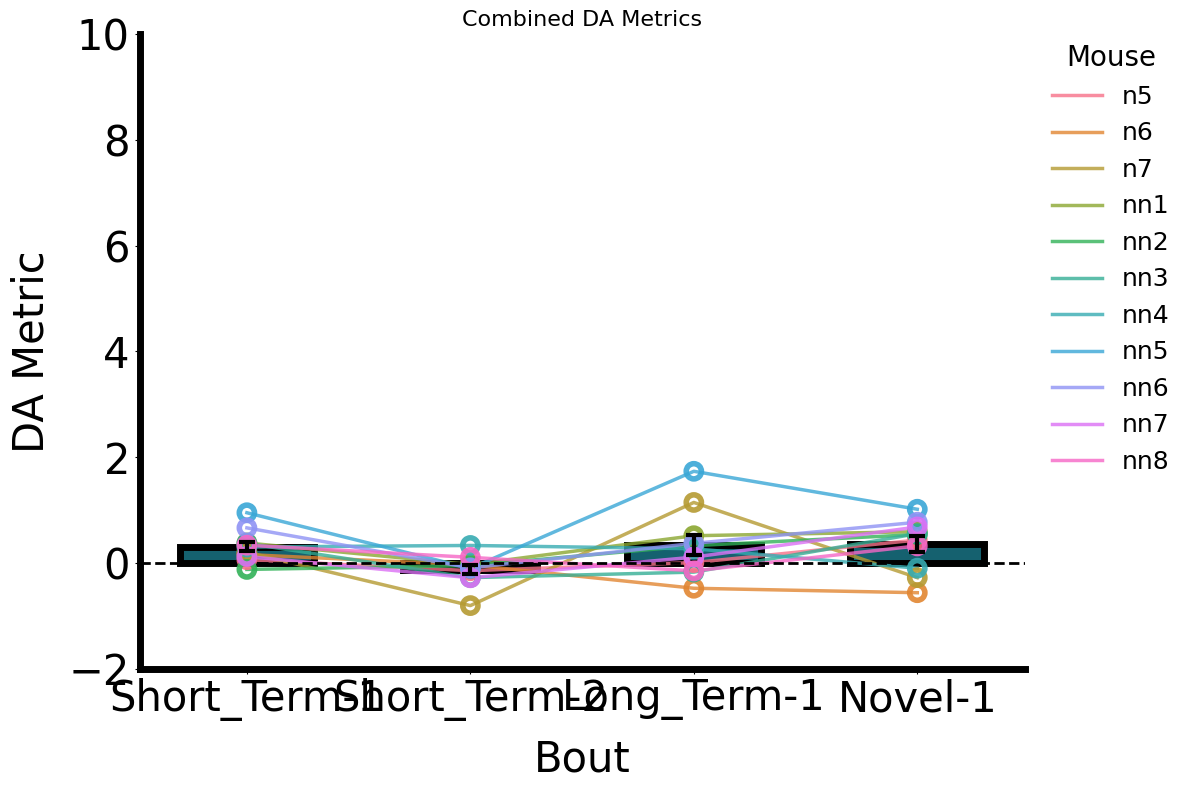

In [26]:
plot_behavior_across_bouts_with_identities(
    metadata_df=nac_ordered_df,
    y_col="Mean Z-score",
    title="Combined DA Metrics", 
    ylabel="DA Metric", 
    xlabel="Bout", 
    custom_xtick_labels=None, 
    custom_xtick_colors=None, 
    ylim=(-2,10), 
    bar_color=nac_color, 
    yticks_increment=None, 
    figsize=(14,8), 
    pad_inches=0.1,
    save=False,
    save_name=None
)

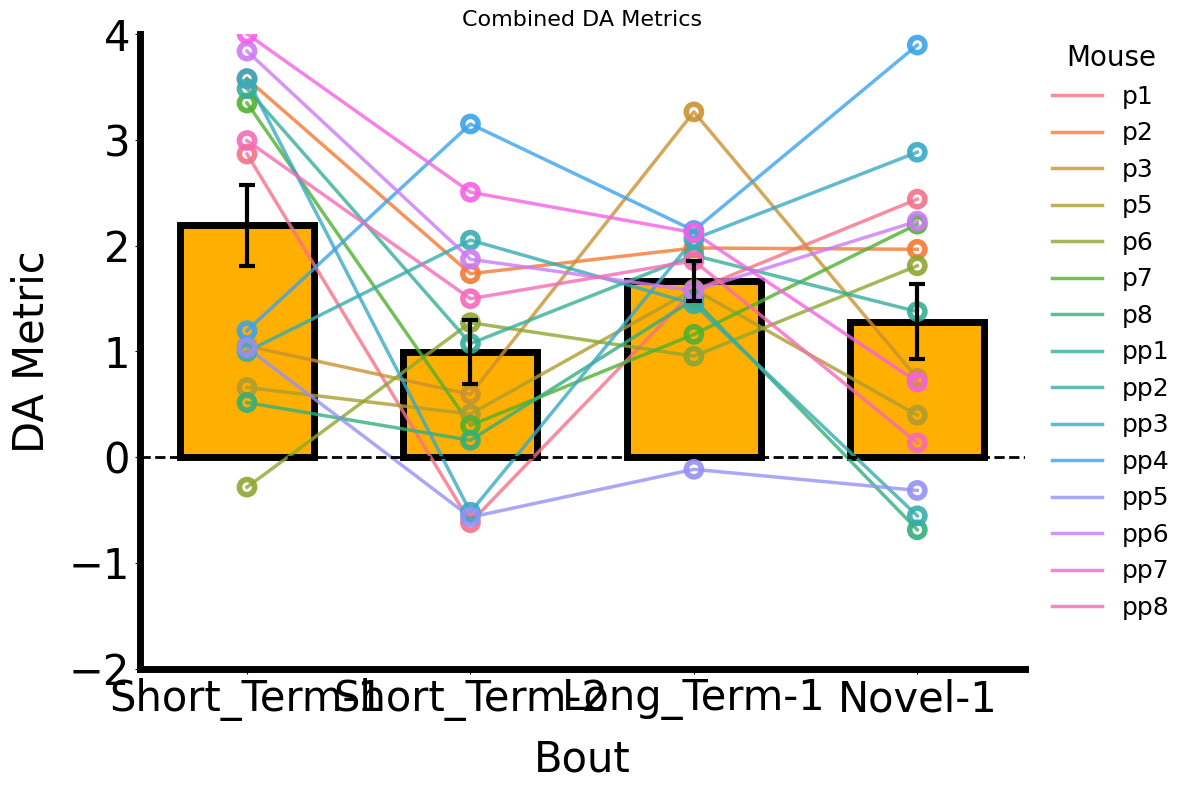

In [27]:
plot_behavior_across_bouts_with_identities(
    metadata_df=mpfc_ordered_df,
    y_col="Max Peak",
    title="Combined DA Metrics", 
    ylabel="DA Metric", 
    xlabel="Bout", 
    custom_xtick_labels=None, 
    custom_xtick_colors=None, 
    ylim=(-2,4), 
    bar_color=mpfc_color, 
    yticks_increment=None, 
    figsize=(14,8), 
    pad_inches=0.1,
    save=False,
    save_name=None
)

In [28]:
nac_exp.reset_all_behaviors()
nac_exp.group_extract_manual_annotations(bout_definitions=bout_definitions, first_only = False)
nac_exp.compute_all_da_metrics(use_max_length=False,
                                  max_bout_duration=4, # total_avg_bout_duration 
                                  mode='standard')

mpfc_exp.reset_all_behaviors()
mpfc_exp.group_extract_manual_annotations(bout_definitions=bout_definitions, first_only = False)
mpfc_exp.compute_all_da_metrics(use_max_length=False,
                                  max_bout_duration=4, # total_avg_bout_duration 
                                  mode='standard')

Processing behaviors for n5-240823-085032...
Processing behaviors for n6-240823-101436...
Processing behaviors for n7-240824-062103...
Processing behaviors for nn1-250120-063024...
Processing behaviors for nn2-250120-072910...
Processing behaviors for nn3-250121-074834...
Processing behaviors for nn4-250121-084228...
Processing behaviors for nn5-250120-081227...
Processing behaviors for nn6-250120-085156...
Processing behaviors for nn7-250121-094048...
Processing behaviors for nn8-250121-101912...
Computing DA metrics for n5-240823-085032 ...
Computing DA metrics for n6-240823-101436 ...
Computing DA metrics for n7-240824-062103 ...
Computing DA metrics for nn1-250120-063024 ...
Computing DA metrics for nn2-250120-072910 ...
Computing DA metrics for nn3-250121-074834 ...
Computing DA metrics for nn4-250121-084228 ...
Computing DA metrics for nn5-250120-081227 ...
Computing DA metrics for nn6-250120-085156 ...
Computing DA metrics for nn7-250121-094048 ...
Computing DA metrics for nn8-2

## DA across Subsequent Bouts

In [29]:
nac_exp_da_dict = get_trial_dataframes(nac_exp)
mpfc_exp_da_dict = get_trial_dataframes(mpfc_exp)

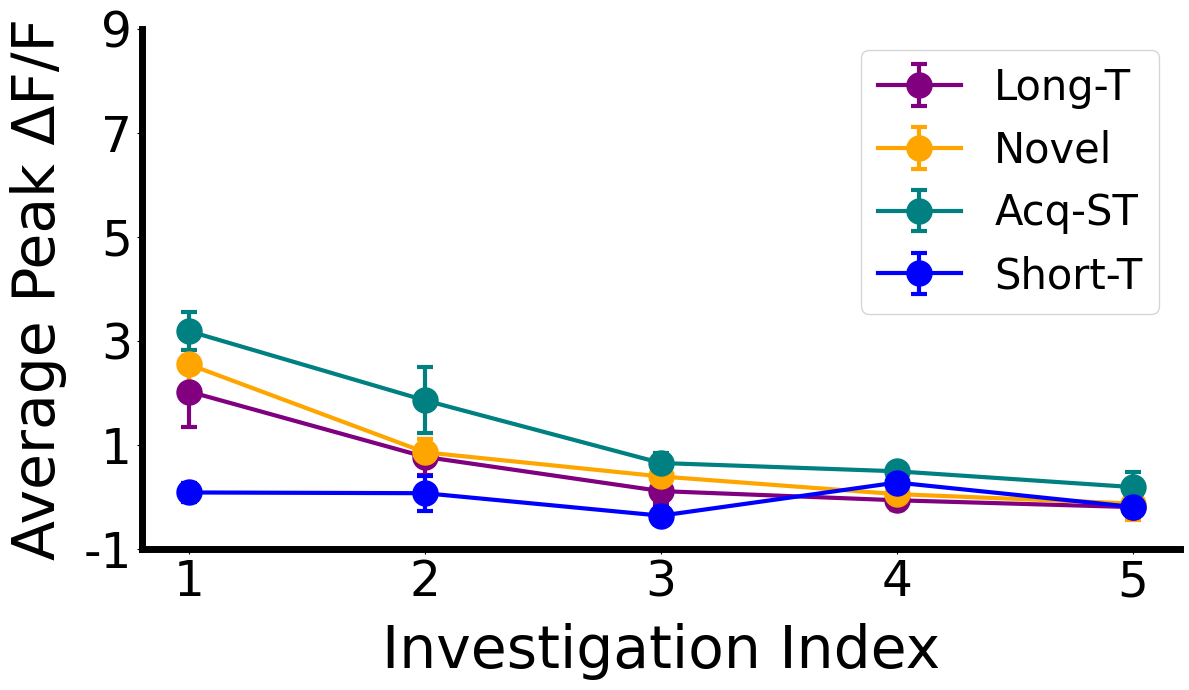


=== Computed Metric (SLOPE): ===
Bout: Long_Term-1, slope = -0.528
Bout: Novel-1, slope = -0.616
Bout: Short_Term-1, slope = -0.737
Bout: Short_Term-2, slope = -0.035


In [31]:
df = plot_peak_for_subsequent_behaviors(
    nac_exp_da_dict,
    behavior="Investigation",
    selected_bouts=["Short_Term-1", "Short_Term-2", "Long_Term-1", "Novel-1"],
    n_subsequent_behaviors=5,
    peak_col="Mean Z-score",
    metric_type='slope', 
    custom_colors={"Short_Term-1": "teal", "Short_Term-2": "blue", "Long_Term-1": "purple", "Novel-1": "orange"},
    custom_legend_labels={"Short_Term-1": "Acq-ST", "Short_Term-2": "Short-T", "Long_Term-1": "Long-T", "Novel-1": "Novel"},
    xlabel="Investigation Index",
    ylabel="Average Peak ΔF/F",
    ylim=(-1, 9),
    ytick_increment=2,
    plot_title="",
    save = False,
    save_path=r"Home_Cage_Plots\mPFC_DA\peaks_for_subsequent_behaviors.png" 
)

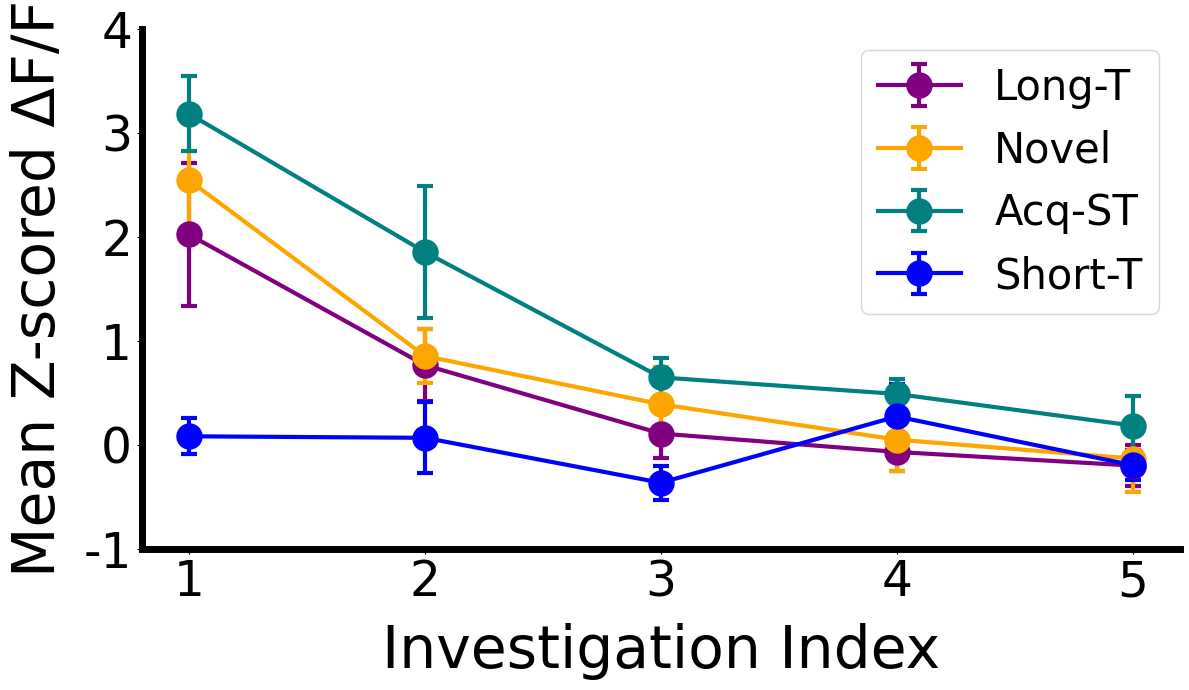


=== Computed Metric (SLOPE): ===
Bout: Long_Term-1, slope = -0.528
Bout: Novel-1, slope = -0.616
Bout: Short_Term-1, slope = -0.737
Bout: Short_Term-2, slope = -0.035


In [32]:
df = plot_peak_for_subsequent_behaviors(
    nac_exp_da_dict,
    behavior="Investigation",
    selected_bouts=["Short_Term-1", "Short_Term-2", "Long_Term-1", "Novel-1"],
    n_subsequent_behaviors=5,
    peak_col="Mean Z-score",
    metric_type='slope', 
    custom_colors={"Short_Term-1": "teal", "Short_Term-2": "blue", "Long_Term-1": "purple", "Novel-1": "orange"},
    custom_legend_labels={"Short_Term-1": "Acq-ST", "Short_Term-2": "Short-T", "Long_Term-1": "Long-T", "Novel-1": "Novel"},
    xlabel="Investigation Index",
    ylabel="Mean Z-scored ΔF/F",
    ylim=(-1, 4),
    ytick_increment=1,
    plot_title="",
    save = False,
    save_path=r"Home_Cage_Plots\mPFC_DA\peaks_for_subsequent_behaviors.png" 
)

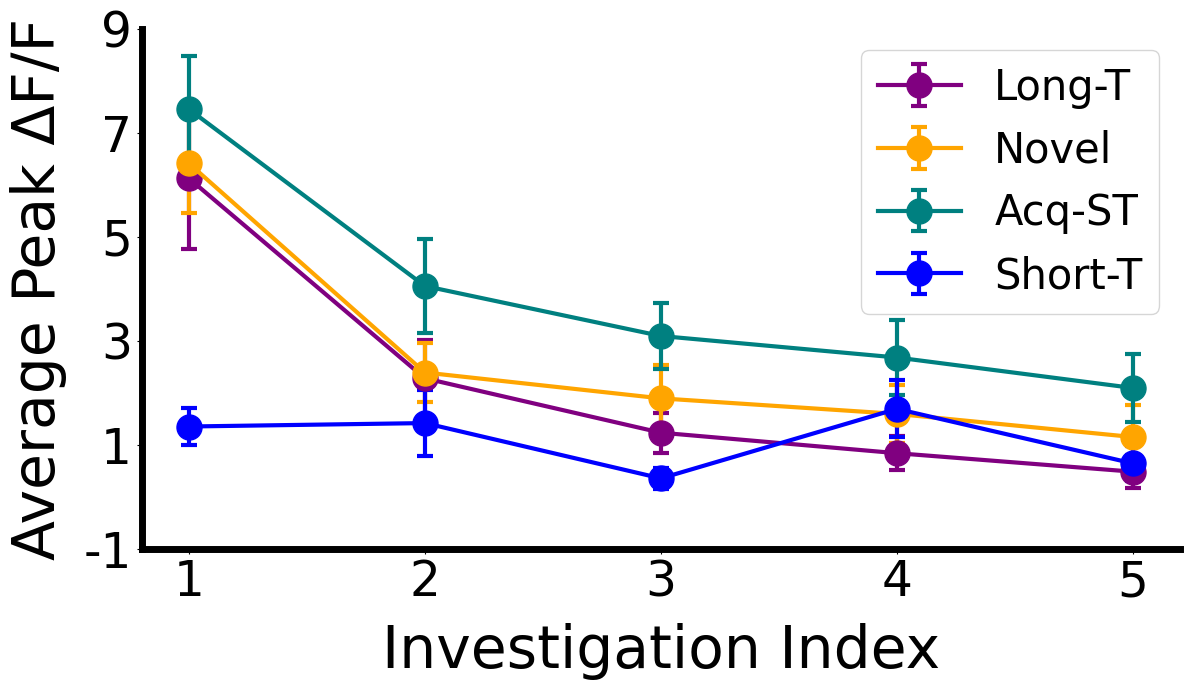


=== Computed Metric (SLOPE): ===
Bout: Long_Term-1, slope = -1.273
Bout: Novel-1, slope = -1.133
Bout: Short_Term-1, slope = -1.210
Bout: Short_Term-2, slope = -0.115


In [33]:
df = plot_peak_for_subsequent_behaviors(
    nac_exp_da_dict,
    behavior="Investigation",
    selected_bouts=["Short_Term-1", "Short_Term-2", "Long_Term-1", "Novel-1"],
    n_subsequent_behaviors=5,
    peak_col="Max Peak",
    metric_type='slope', 
    custom_colors={"Short_Term-1": "teal", "Short_Term-2": "blue", "Long_Term-1": "purple", "Novel-1": "orange"},
    custom_legend_labels={"Short_Term-1": "Acq-ST", "Short_Term-2": "Short-T", "Long_Term-1": "Long-T", "Novel-1": "Novel"},
    xlabel="Investigation Index",
    ylabel="Average Peak ΔF/F",
    ylim=(-1, 9),
    ytick_increment=2,
    plot_title="",
    save = False,
    save_path=r"Home_Cage_Plots\mPFC_DA\peaks_for_subsequent_behaviors.png" 
)

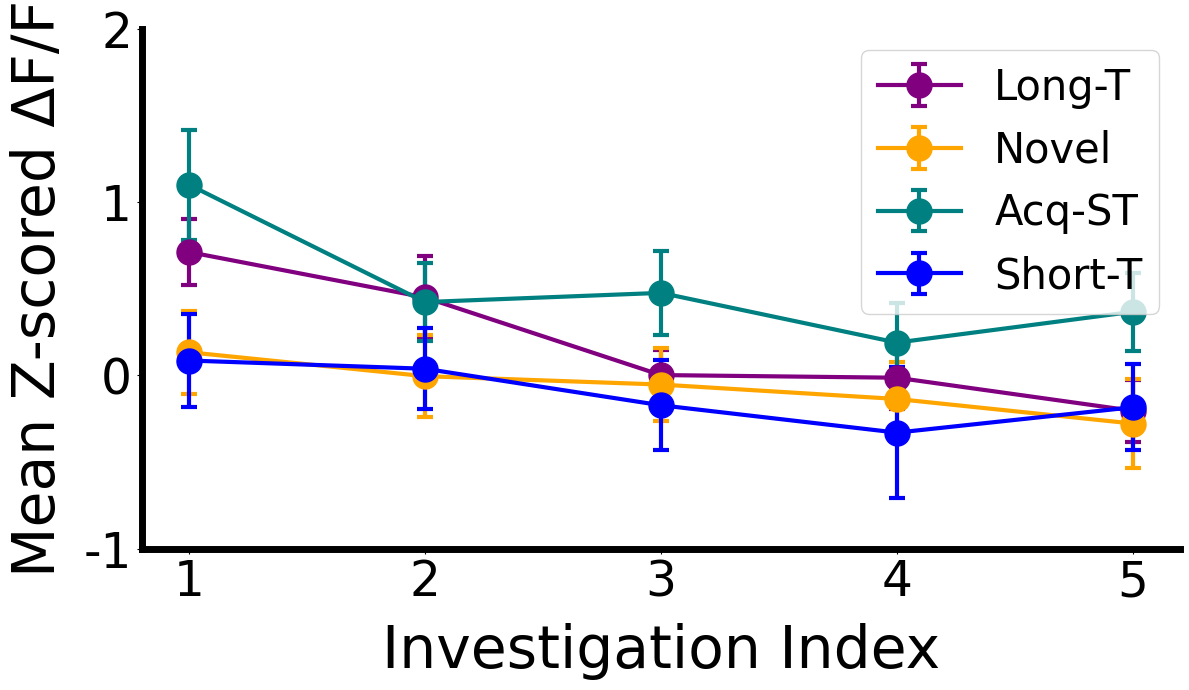


=== Computed Metric (SLOPE): ===
Bout: Long_Term-1, slope = -0.230
Bout: Novel-1, slope = -0.095
Bout: Short_Term-1, slope = -0.170
Bout: Short_Term-2, slope = -0.091


In [60]:
df = plot_peak_for_subsequent_behaviors(
    mpfc_exp_da_dict,
    behavior="Investigation",
    selected_bouts=["Short_Term-1", "Short_Term-2", "Long_Term-1", "Novel-1"],
    n_subsequent_behaviors=5,
    peak_col="Mean Z-score",
    metric_type='slope', 
    custom_colors={"Short_Term-1": "teal", "Short_Term-2": "blue", "Long_Term-1": "purple", "Novel-1": "orange"},
    custom_legend_labels={"Short_Term-1": "Acq-ST", "Short_Term-2": "Short-T", "Long_Term-1": "Long-T", "Novel-1": "Novel"},
    xlabel="Investigation Index",
    ylabel="Mean Z-scored ΔF/F",
    ylim=(-1, 2),
    ytick_increment=1,
    plot_title="",
    save = False,
    save_path=r"Home_Cage_Plots\mPFC_DA\peaks_for_subsequent_behaviors.png" 
)

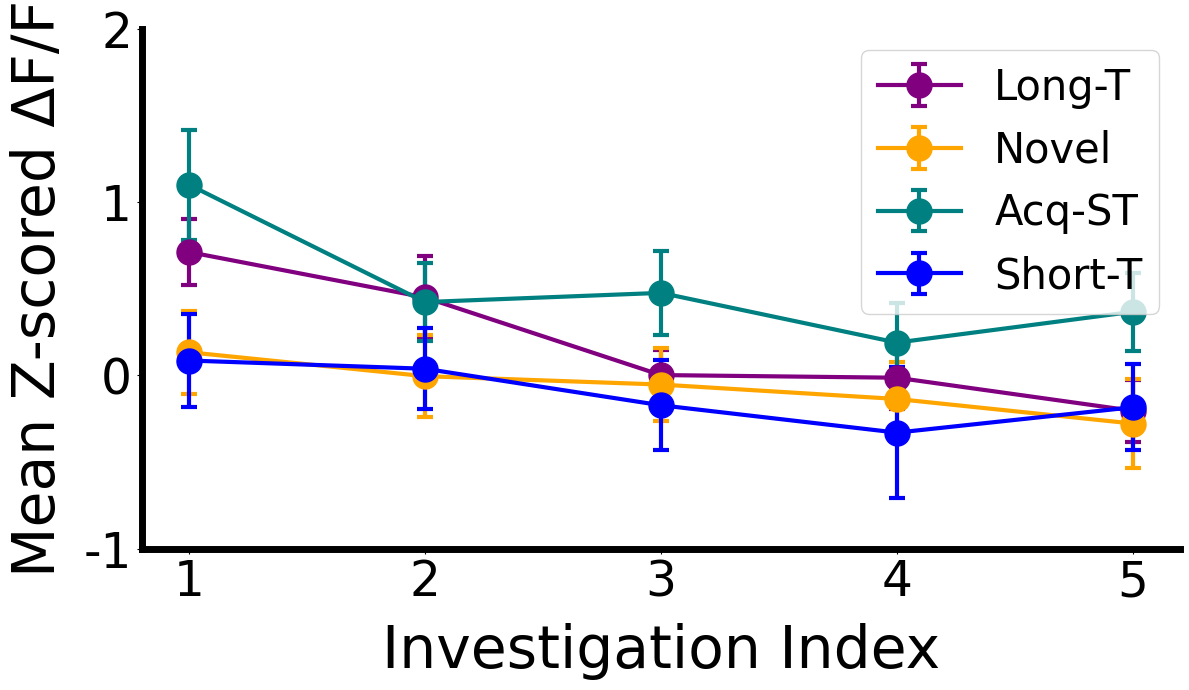


=== Computed Metric (SLOPE): ===
Bout: Long_Term-1, slope = -0.230
Bout: Novel-1, slope = -0.095
Bout: Short_Term-1, slope = -0.170
Bout: Short_Term-2, slope = -0.091


In [ ]:
df = plot_peak_for_subsequent_behaviors(
    mpfc_exp_da_dict,
    behavior="Investigation",
    selected_bouts=["Short_Term-1", "Short_Term-2", "Long_Term-1", "Novel-1"],
    n_subsequent_behaviors=5,
    peak_col="Mean Z-score",
    metric_type='slope', 
    custom_colors={"Short_Term-1": "teal", "Short_Term-2": "blue", "Long_Term-1": "purple", "Novel-1": "orange"},
    custom_legend_labels={"Short_Term-1": "Acq-ST", "Short_Term-2": "Short-T", "Long_Term-1": "Long-T", "Novel-1": "Novel"},
    xlabel="Investigation Index",
    ylabel="Mean Z-scored ΔF/F",
    ylim=(-1, 2),
    ytick_increment=1,
    plot_title="",
    save = False,
    save_path=r"Home_Cage_Plots\mPFC_DA\peaks_for_subsequent_behaviors.png" 
)